In [75]:
# imports
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

# <div align="center">**The Planet in a Box: An Energy Balance Model of Global Warming**</div>

### <div align="center">MOD300 Mandatory project 2 </div>

<div align="center">Written by Jone Bakken & Petter Worpvik Tverdal</div>

<br>

<div align="center">! submission date !</div>

## Abstract

## Introduction

In this project, we use a two-box energy-balance model to show how the climate responds to changes in greenhouse gas forcing, how quickly temperatures adjust, and how the response changes when forcing is reduced. Apart from the climate application, the project applies many ideas from mathematical modelling: translating conservation laws into ordinary differential equations, implementing a reusable numerical solver, and comparing numerical results to known behavior and an independent method.

The two-box model represents the system with two connected boxes. The upper box is the atmosphere and well-mixed upper ocean. This box responds relatively quickly, while the lower box represents the deep ocean. The lower box responds slower because of how large the heat capacity is. The variables $T$ and $T_0$ are temperature anomalies relative to the pre-industrial equilibrium. Forcing adds energy to the upper box. Radiative damping acts as a counter to the temperature anomaly, and heat exchange transfers energy between the boxes. This model acts as a simplification, it does not represent every process in the climate, but still provides a way to understand the combined effect of all the mechanisms we will go through.

This report will first explain the physical meaning and units of the energy balances, then calculate the equilibrium temperature of an idealized Earth without an atmosphere. Then, we implement a general ODE solver and validate this using what we know from the equilibrium, a SciPy solution, and a time step stability analysis.

! mention what is done in  exercise 3 and 4

We conclude the report by introducing a nonlinear feedback with ice albedo to look at system thresholds and hysteresis.

In all, we progress from exploring the physical and numerical foundations to testing the effects of additional climate mechanisms.

! also include the optional exercise if done

## 1. Fundamentals of the two-box model

Before applying the energy balance model, we establish what its two boxes and balance terms represent. The upper box combines the atmosphere and well-mixed upper ocean, while the lower box represents the deep ocean. Their temperatures, $T$ and $T_0$, are anomalies relative to the pre-industrial state. The deep ocean responds slower because it has a larger heat capacity.

The energy balances for the upper and lower boxes are:

$$ C \frac{dT}{dt} = F(t) - \lambda T - \gamma (T-T_0) \tag{1}$$
$$ C_0 \frac{dT_0}{dt} = \gamma (T-T_0) \tag{2}$$

We will first draw energy flows and check the units, then look at the radiative equilibrium for an idealized Earth without an atmosphere.

### 1.1 Visualizing the model

By identifying the energy flows in the two-box model, we can connect terms in the equations to a physical process. This way, it will be clear why some variables are positive or negative when we do calculations with the model.

To correctly identify the energy flows, we need to understand what the variables mean:
- The forcing $F(t)$ is the external energy added to the climate system.
- Radiative damping, $-\lambda T$, is the energy lost as the system heats up. It is a stabilizing effect, meaning that a higher temperature $T$, leads to more energy removed.
- Heat exchange $\gamma (T-T_0)$ is the physical flow of heat between the mixed layer and deep ocean.

<figure align="center">
    <img src="figures/1.1-energy-flow.png" width="700">
    <figcaption style="text-align: left"> Figure 1: Energy flow of the approximated two-box model, showing directions of the forcing, radiative damping and heat exchange.</figcaption>
</figure>

The arrows show the chosen directions for energy flows in the two-box approximation.

In the upper-box balance (1), each term has a fixed sign in the equation: $+F(t)$ adds energy to the upper box, while $-\lambda T$ and $-\gamma(T-T_0)$ remove energy from it when $T>0$ and $T>T_0$.

Positive forcing adds energy to the upper box, so the $F(t)$ arrow points into the mixed layer. Radiative damping releases energy into space, so its arrow points upwards.

When $T>T_0$, heat flows from the upper box into the deep ocean. If $T_0>T$, the heat exchange direction reverses.

The heat-exchange terms have opposite signs in equations (1) and (2). When the equations are added, these terms cancel, showing that heat exchange transfers energy between the boxes but does not create or remove energy from the two-box system.

### 1.2 Checking the units

Having clarified how energy moves between the boxes, we now check that the terms in the two-box equations are dimensionally consistent. We first leave the time unit as a variable, then compare the calculated heat capacity units with their given units. This way, we can confirm the time unit of the model.

The temperatures $T$ and $T_0$ are temperature anomalies measured in Kelvin. Their rates of change have units $\frac{K}{\text{time}}$. The energy flow terms $F(t)$, $\lambda T$ and $\gamma (T-T_0)$ are measured in energy flow per unit area: $\frac{W}{m^{2}}$.

Using equation (1) and the units we already know, we can determine the unit of heat capacity in the upper box, $C$:

$$ [C] \cdot [\frac{dT}{dt}] = [F(t) - \lambda T - \gamma (T-T_0)] $$

$$ \implies [C] = \frac {W/m^2} {K / \text{time}} = \frac{W}{m^2} \cdot \frac{\text{time}}{K}
= \frac{W\cdot \text{time}}{m^2 \cdot K} $$

With equation (2) we can confirm that the units of heat capacities match:

$$ [C_0] = \frac{[\gamma (T-T_0)]}{[dT_0/dt]} $$
$$ \implies [C_0] = \frac{W/m^2}{K/\text{time}} = \frac{W\cdot \text{time}}{m^2 \cdot K} = [C]$$

Comparing this with the given values of $C$ and $C_0$, which are in units of $\frac{W \cdot \text{yr}}{m^2 \cdot K}$, shows that the model's time unit is years.

Performing a unit check like this confirms the consistency of the equations before proceeding with the model. Since time is measured in years, all time arrays and step sizes in the solver will also be given in years.

### 1.3 Solar constant and planetary albedo

Going forward in this chapter, we consider a simplified Earth without an atmosphere, radiating as a simple blackbody straight to space without trapping heat. This shows why a finished two-box model needs more terms, apart from simple blackbody radiation.

In later calculations, the solar constant $S_0$ and the planetary albedo $\alpha$ are both essential. We will therefore look at what these terms mean.

The solar constant $S_0 = 1361 W/m^2$ is the incoming solar power per unit area at Earth's average distance from the Sun. It describes the solar energy available at the top of the atmosphere before any reflection or absorption.

The planetary albedo $\alpha = 0.30$ is the fraction of solar radiation that is reflected back to space. Bright surfaces, like clouds, ice, and snow have a high albedo. The albedo is given as a fraction. This means that it ranges from zero to one, with $\alpha=1$ meaning all sunlight is reflected. In calculations, we are usually interested in the remaining fraction $(1-\alpha)$, which is the fraction of sunlight that is absorbed and can heat the planet.

Together, $S_0$ and $\alpha$ determine the absorbed solar flux: $S_0$ is the incoming power per unit area, while $1-\alpha$ is the fraction absorbed.

### 1.4 Absorbed solar power

Since the Earth only catches sunlight from one direction, we calculate the incoming energy using the area of a flat circle rather than the full sphere. This area, $A$, is:

$$A=\pi R^2,$$

where $R$ is Earth's radius.

The solar constant $S_0$ gives the power per unit area hitting this area. As explained, the fraction $(1-\alpha)$ is absorbed. Multiplying the incoming flux $S_0$ by $(1-\alpha)$ and by the area $A=\pi R^2$ gives the total absorbed power:

$$ P_{abs} = S_0 \cdot (1-\alpha) \cdot A = S_0(1-\alpha) \cdot \pi R^2$$

This shows that the amount of solar power Earth absorbs depends on three factors: The sunlight intensity ($S_0$), how much is absorbed ($1-\alpha$), and how much area that actually intercepts it ($A=\pi R^2$).

### 1.5 Radiative equilibrium

Unlike the incoming sunlight, the Earth emits heat from its entire surface, not just one side. Assuming the earth is a sphere, the total surface area is $4 \pi R^2$. With a power emitted per unit area of $\sigma T^4$, the total power is: 

$$P_{emit} = 4 \pi R^2 \sigma T^4$$

$T$ here is an absolute temperature in Kelvin, not a temperature anomaly as in the two-box model. 

At radiative equilibrium, absorbed and emitted power are equal, $P_{abs} = P_{emit}$, and the temperature gets its equilibrium value $T = T_{eq}$:

$$P_{emit} = 4 \pi R^2 \sigma T_{eq}^4$$

Inserting $P_{abs}$ from earlier gives:

$$S_0(1-\alpha) \pi R^2 = \sigma T_{eq}^4 \cdot 4 \pi R^2$$

Since the area $\pi R^2$ appears on both sides, we can cancel it and get a way to solve for the equilibrium temperature, $T_{eq}$:

$$\sigma T_{eq}^4 = \frac{S_0(1-\alpha)}{4}$$
$$\implies T_{eq} = \left( \frac{S_0(1-\alpha)}{4\sigma} \right) ^{1/4}$$

To check the units, $S_0$ is in $W/m^2$ and $\alpha$ has no unit, so the numerator has units $W/m^2$. The Stefan-Boltzmann constant $\sigma$ has units $W/(m^2K^4)$, so dividing gives units of $K^4$. Taking the fourth root gives units of $K$, confirming that the equilibrium temperature is in Kelvin.

Balancing the energy budget reveals the equilibrium temperature. The radius of the Earth cancels out, leaving a temperature determined by $S_0$, $\alpha$ and $\sigma$.


### 1.6 Interpreting the cold-Earth result

Using the equilibrium expression above, we will calculate the temperature of an atmosphere free Earth, and compare it with the observed global mean surface temperature.

Substituting $S_0 = 1361 W/m^2$, $\alpha = 0.30$, and $\sigma = 5.670 \cdot 10^{-8} \frac{W}{(m^2 K^4)}$ gives

$$ T_{eq} = \left(  \frac{1361 \cdot (1-0.30)}{4 \cdot (5.670 \cdot 10^{-8})} \right)^{1/4} \approx 254.6 \text{ K}$$

Converting to degrees Celsius:

$$ T_{eq} \approx 254.6 - 273.15 = -18.6^\circ \text{C}$$

The observed global mean surface temperature is about $288 \text{ K}$ , which is about $15 ^\circ \text{C}$. It is $33.4$ K  warmer than our calculated $T_{eq} = 254.6 \text{ K}$.

This estimate is much colder than the observed mean surface temperature of the Earth. The difference is mainly caused by the greenhouse effect. This means that the real atmosphere absorbs a lot of the radiation emitted by the surface, and sends some of it back down. Therefore, the surface must be warmer than $T_{eq}$ if the planet should emit the same amount of energy to space as it absorbs. The $33.4 \text{ K}$ difference shows why a realistic climate model needs to include the atmosphere, not only absorbed sunlight and blackbody emission.

### 1.7 Conclusion

We have now explored the physical meaning of the two-box model. The forcing $F(t)$ adds energy to the upper box, radiative damping $\lambda T$ removes it to space, and the exchange term $\gamma(T-T_0)$ moves heat between the boxes. The unit check showed that $C$ and $C_0$ have units $W \cdot \text{yr}/(m^2 K)$, so time in the model is measured in years, which we will use in the solver to be implemented next.

Without an atmosphere to trap heat, balancing the energy the Earth absorbs from the sun with the heat it emits gives an expected temperature $T_{eq} \approx -18.6^\circ \text{C}$, equalling $254.6 \text{ K}$. This is $33^\circ \text{C}$ colder than reality, clearly showing how much the atmosphere helps with warming.

Together, the unit check shows that the equations are consistent, and the cold-Earth result shows why the atmosphere must be included in a climate model. With this foundation, we can now build a numerical solver for the model.

## 2. Building the ODE solver

After establishing the physical meaning and units of the two-box model, we can now translate it into a reusable numerical solver. We first formulate and test the solver, then check its equilibrium and compare the solution with SciPy. Finally, we use a varied step size in the Forward Euler method to compare with 4th order Runge-Kutta to find numerical instability.

### 2.1 Formulating the model and implementing a solver

We define the state vector as $\text{y}=(T,T_0)$. Dividing equations (1) and (2) by their heat capacities gives:

$$
\frac{d\text{y}}{dt}=\text{f}(\text{y},t)=
\begin{bmatrix}
\bigl(F(t)-\lambda T-\gamma(T-T_0)\bigr)/C \\
\gamma(T-T_0)/C_0
\end{bmatrix}
$$

We can then generalize this to an ODE of the form:

$$ \frac{d\text{y}}{dt}=\text{f}(\text{y},t,*\text{args}),$$

where the right hand side is the rate of change, and $\text{*args}$ allows for any additional model parameters or forcing functions needed. The reusable solver does not need any details of the climate model, it simply accepts the derivative function, initial state, time array and additional arguments. It uses each actual interval $h_i=t_{i+1}-t_i$.

The model is implemented in the following code snippet:

In [76]:
class TwoBoxModel:
    def __init__(self):
        self.C = 7.3
        self.C0 = 106.0
        self.lam = 1.13
        self.gamma = 0.73


def ebm_rhs(y, t, model, forcing):
    T, T0 = y
    F = forcing(t)
    dT_dt = (F - model.lam * T - model.gamma * (T - T0)) / model.C
    dT0_dt = model.gamma * (T - T0) / model.C0
    return np.array([dT_dt, dT0_dt])


def euler_step(f, delta_t, y_old, t_old, *args):
    return delta_t * f(y_old, t_old, *args)


def rk4_step(f, delta_t, y_old, t_old, *args):
    k1 = delta_t * f(y_old, t_old, *args)
    k2 = delta_t * f(y_old + 0.5 * k1, t_old + 0.5 * delta_t, *args)
    k3 = delta_t * f(y_old + 0.5 * k2, t_old + 0.5 * delta_t, *args)
    k4 = delta_t * f(y_old + k3, t_old + delta_t, *args)
    return (k1 + 2 * k2 + 2 * k3 + k4) / 6


def solver(f, y0, t, *args, method="RK4"):
    """
    f: right hand side of ODE f(y, t, *args)
    y0: initial condition at time t[0]
    t: array of time values (the spacing does not have to be equal)
    *args: arguments to f
    method: 'Euler' or 'RK4'

    return solution array with shape (len(t), len(y0))
    """
    if method == "Euler":
        step = euler_step
    elif method == "RK4":
        step = rk4_step
    else:
        print("Method not implemented.")
        return

    y = [y0]  # list to store the solution
    y_old = y0
    for i in range(len(t) - 1):
        delta_t = t[i + 1] - t[i]  # actual interval for this step
        y_new = y_old + step(f, delta_t, y_old, t[i], *args)
        y.append(y_new)
        y_old = y_new
    return np.array(y)


def test_forcing(time):
    return 4.0


# Short test if it works when time steps are unevenly spaced.
model = TwoBoxModel()
y0 = np.array([0.0, 0.0])
t_short = np.array([0.0, 0.25, 0.75, 1.0])
solution_rk4 = solver(ebm_rhs, y0, t_short, model, test_forcing, method="RK4")
solution_euler = solver(ebm_rhs, y0, t_short, model, test_forcing, method="Euler")

print("Expected shape:", (len(t_short), len(y0)))
print("Shape of RK4:", solution_rk4.shape, " Shape of Euler:", solution_euler.shape)
print("Initial state:", y0)
print("First row RK4:", solution_rk4[0], " First row Euler:", solution_euler[0])

Expected shape: (4, 2)
Shape of RK4: (4, 2)  Shape of Euler: (4, 2)
Initial state: [0. 0.]
First row RK4: [0. 0.]  First row Euler: [0. 0.]


The short test uses a nonuniform time array and runs both Euler and RK4. For each method, the solution has shape $(\text{len}(t),\text{len}(y_0))=(4,2)$, and its first row matches the supplied initial state. This confirms the solver interface and basic output.

With the check complete, we will test whether the solver reproduces the model equilibrium we know, under constant forcing.


### 2.2 Equilibrium and solver validation

Now that the solver is built, we check that it gives the right answers. First, we find the temperatures the model should end up at under a constant forcing $F_0$. At equilibrium the temperatures no longer change, so we set the derivatives equal to zero.

The lower box only changes through heat exchange with the upper box:

$$
0=\gamma(T_{eq}-T_{0,eq}) \quad\Longrightarrow\quad T_{eq}=T_{0,eq}
$$

Since $\gamma\ne0$, the heat flow only stops when the two boxes have the same temperature. The exchange term in the upper-box balance is then zero, which gives:

$$
0=F_0-\lambda T_{eq} \quad\Longrightarrow\quad T_{eq}=T_{0,eq}=\frac{F_0}{\lambda}
$$

At equilibrium, the energy added by the forcing equals the energy radiated to space. The heat capacities do not appear in the result: they decide how fast the boxes reach equilibrium, but not where it is.

For a $\text{CO}_2$ doubling, the forcing is $F_{2\times}=5.35\ln 2$. The equilibrium climate sensitivity (ECS) is the warming we get after doubling $\text{CO}_2$ and waiting until the temperatures settle:

$$
\mathrm{ECS}=\frac{F_{2\times}}{\lambda}
$$

In [77]:
def constant_forcing(time):
    return 5.35 * np.log(2.0)  # CO2 doubling

model = TwoBoxModel()
F2x = constant_forcing(0)
T_equilibrium = F2x / model.lam  # equal to the ECS

print("F2x =", round(F2x, 3), "W/m^2")
print("ECS =", round(T_equilibrium, 2), "K")

F2x = 3.708 W/m^2
ECS = 3.28 K


With the default $\lambda=1.13  \text{W}/(m^2 \text{K})$, we get $\text{ECS}\approx3.28 \text{ K}$. Since a change of $1 \text{K}$ is the same as a change of $1^\circ \text{C}$, this is $3.28 ^\circ \text{C}$, which lies within the IPCC AR6 range of $2.5$ - $4 ^\circ \text{C}$. The default parameters therefore give a realistic climate sensitivity.

Next, we check the solver. Starting with both temperatures at zero, we run RK4 for 3000 years with a step of 1 year, and again with 0.5 years. The two boxes have very different response times: about 4 years for the upper box and about 240 years for the deep ocean (these come from the two eigenvalues of the system). For every 240 years, the remaining distance to equilibrium gets about 2.7 times smaller, so after 3000 years it is only around $10^{-5} \text{ K}$, which is small enough to count as equilibrium. We compare both methods with the reference solver `solve_reference`. It uses SciPy's `solve_ivp` with the Radau method and strict error tolerances, and takes the same arguments and returns the same shape as our solver, so the results can be compared directly.

h = 1.0 yr: max difference from Radau = 3.262029495187946e-05 K
h = 0.5 yr: max difference from Radau = 1.8299909960717287e-06 K
Temperatures after 3000 years (T, T_0): [3.28170914 3.28170103] K


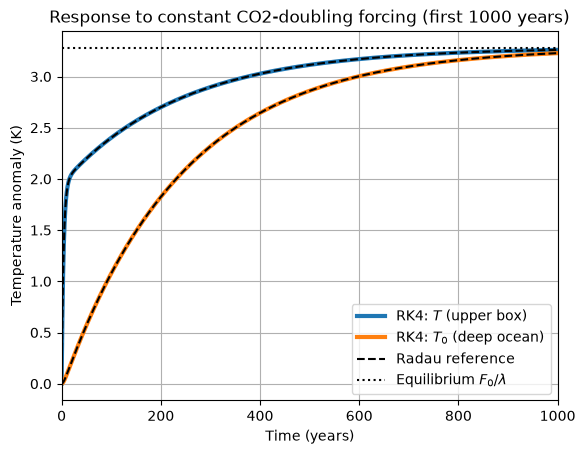

In [78]:
# Reference solver supplied in the project description
def solve_reference(f, y0, t, *args):
    def scipy_rhs(time, state):
        return f(state, time, *args)

    sol = solve_ivp(
        scipy_rhs,
        (t[0], t[-1]), y0, method="Radau", t_eval=t,
        rtol=1e-8, atol=1e-10,
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol.y.T


y0 = np.array([0.0, 0.0])

for h in [1.0, 0.5]:
    t = np.arange(0, 3000 + h, h)
    solution_rk4 = solver(ebm_rhs, y0, t, model, constant_forcing, method="RK4")
    reference = solve_reference(ebm_rhs, y0, t, model, constant_forcing)
    print("h =", h, "yr: max difference from Radau =", np.max(np.abs(solution_rk4 - reference)), "K")

print("Temperatures after 3000 years (T, T_0):", solution_rk4[-1], "K")

plt.plot(t, solution_rk4[:, 0], label="RK4: $T$ (upper box)", linewidth=3)
plt.plot(t, solution_rk4[:, 1], label="RK4: $T_0$ (deep ocean)", linewidth=3)
plt.plot(t, reference[:, 0], "k--", label="Radau reference")
plt.plot(t, reference[:, 1], "k--")
plt.axhline(T_equilibrium, color="k", linestyle=":", label="Equilibrium $F_0/\\lambda$")
plt.xlim(0, 1000)
plt.xlabel("Time (years)")
plt.ylabel("Temperature anomaly (K)")
plt.title("Response to constant CO2-doubling forcing (first 1000 years)")
plt.legend()
plt.grid()
plt.show()

After 3000 years, both temperatures are $3.2817 \text{ K}$, the same as $F_0 / \lambda$. The solver therefore reaches the equilibrium we derived by hand.

The figure shows the first 1000 years, where the changes happen. The upper box warms to about $2 \text{ K}$ very fast, while the deep ocean, with a much larger heat capacity, warms slowly over the years. The dashed Radau curves are on top of the RK4 curves.

The differences between RK4 and Radau are also printed above. We got the biggest difference of $3.3\cdot 10^{-5} \text{ K}$ with a step size of 1 year, and $1.8 \cdot 10^{-6} \text{ K}$ with a 0.5 year step. Halving the step makes the error about 18 times smaller.

The solver reaches the equilibrium calculated by hand. It follows the same path as the reference solver, and becomes more accurate when the step is reduced. The ECS of $3.28 ^\circ \text{C}$ is in the IPCC range.


### 2.3 Investigating solver stability


The previous checks confirm the model and RK4 solver work at a stable step size. Now, we vary the step size to compare Forward Euler with RK4. This helps us tell whether any oscillation or growth comes from the numerical method rather than from the physical model.

Euler h = 1 yr: max |T| = 2.11 K
Euler h = 2 yr: max |T| = 2.11 K
Euler h = 4 yr: max |T| = 2.1 K
Euler h = 7 yr: max |T| = 3.56 K
Euler h = 8 yr: max |T| = 4.4 K
Euler h = 10 yr: max |T| = 9.74 K


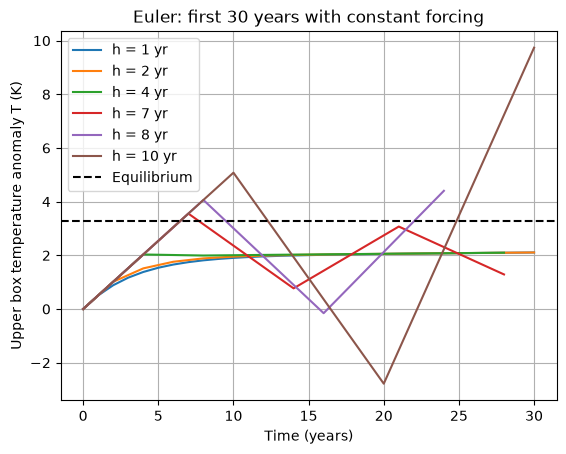

RK4 h = 1 yr: max |T| = 2.11 K
RK4 h = 2 yr: max |T| = 2.11 K
RK4 h = 4 yr: max |T| = 2.1 K
RK4 h = 7 yr: max |T| = 2.08 K
RK4 h = 8 yr: max |T| = 1.99 K
RK4 h = 10 yr: max |T| = 1.36 K


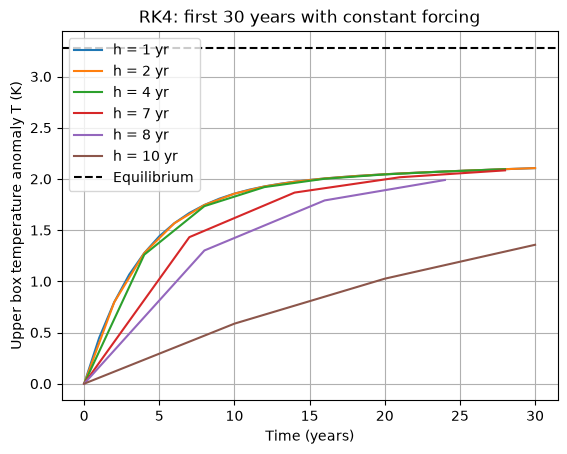

In [79]:
step_sizes = [1, 2, 4, 7, 8, 10]


for method in ["Euler", "RK4"]:
    for h in step_sizes:
        t = np.arange(0, 31, h)  # first 30 years
        solution = solver(ebm_rhs, y0, t, model, constant_forcing, method=method)
        plt.plot(t, solution[:, 0], label="h = " + str(h) + " yr")
        print(method, "h =", h, "yr: max |T| =", round(np.max(np.abs(solution[:, 0])), 2), "K")

    plt.axhline(T_equilibrium, color="k", linestyle="--", label="Equilibrium")
    plt.xlabel("Time (years)")
    plt.ylabel("Upper box temperature anomaly T (K)")
    plt.title(method + ": first 30 years with constant forcing")
    plt.legend()
    plt.grid()
    plt.show()

We only look at the first 30 years and the upper box, because this is where the temperature changes fastest, and where problems with a large step will show up first. As mentioned in 2.2, the upper box responds in about 4 years, so a step of several years is already long compared to how fast the box changes.

For Forward Euler, the curves for $h=1$, $2$ and $4$ years look almost the same, and the highest temperature is about $2.1 \text{ K}$ in all three. At $h=7$ years the curve starts to jump up and down around the right answer, but the jumps get smaller over time. At $h=8$ years the jumps get bigger for each step instead, and at $h=10$ years the solution blows up completely, with the highest temperature reaching $9.7 \text{ K}$. That is far above the equilibrium of $3.28 \text{ K}$, which the model should never go above when starting from zero. With $h=8$ and $h=10$ years the temperature even drops below zero, to $-0.16 \text{ K}$ and $-2.78 \text{ K}$, which also makes no physical sense, since the forcing only adds energy.

RK4 on the other hand stays stable for all the step sizes. For small steps the curves are on top of each other, but at $h=10$ years the curve is clearly too low. After 10 years it gives $0.59 \text{ K}$, while the small steps give about $1.86 \text{ K}$, so the method is still stable but not very accurate anymore.

The equations and the forcing are exactly the same in every run, and the only thing we change is $h$. This means that the oscillations are not something the climate actually does, but something that is made by the numerical method.

##### ! explain:
 why euler breaks down between 7 and 8 years, using a d = T-T_eq (distance from equilibrium) - and see that it matches what we see in the plot. - and how rk4 avoids this unstability by using four slopes instead of one.

To sum up, Forward Euler becomes unstable between $h=7$ and $h=8$ years. RK4 stays stable for all the steps we tested, but gets less accurate for large steps. For the rest of the project we therefore use RK4 with $h\le1$ year, or the Radau reference solver.

### 2.4 Conclusion

In this exercise we built our own ODE solver and checked that we can trust it. ...

## 3. 

## 4. 

## 5. Nonlinear feedback and hysteresis


## 6. (Optional)

## Summary

summarize the whole project

#### Reflection: Jone



#### Reflection: Petter

## References